### Bayesian spectral fitting with SpammsFit

This notebook demonstrates how to perform bayesian fitting of an observed spectrum using SPAMMSFit.

SpammsFit is used directly from the source dir and no need for any pre-installation required. A local SPAMMS installation is needed but not necessarily should be in the same  dir as SpammsFit.

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

In [2]:
SPAMMSFIT_DIR = Path.home() / "SpammsFit" # Path to the local SpammsFit repository.
SPAMMSFIT_SRC = SPAMMSFIT_DIR / "src" # temporarily import the spammsfit source package 
if not SPAMMSFIT_SRC.is_dir():
    raise FileNotFoundError(f"Could not find the SpammsFit source directory: {SPAMMSFIT_SRC}")
if str(SPAMMSFIT_SRC) not in sys.path:
    sys.path.insert(0, str(SPAMMSFIT_SRC))
import spammsfit as spfit
import spammsfit.plotting as spplot

#### Configure SpammsFit to point to the local SPAMMS installation

In [3]:
SPAMMS_DIR = Path.home() / "PhD_stuff" / "SPAMMS" # Change this path to the user's local SPAMMS installation.
config = spfit.SpammsConfig(
    spamms_directory=SPAMMS_DIR,
    spamms_script=SPAMMS_DIR / "spamms.py", #path to the local main spamms.py file
    temporary_directory=SPAMMSFIT_DIR / "examples" / "outputs" / "bayesian_temp",  #temporary file storage during spamms runs
    results_directory=SPAMMSFIT_DIR / "examples" / "results" / "bayesian_results", # output folder
    )

#### Load data

We are using an example spectrum of a HeII 4200 profile for a star with $T_{eff}$ = 40000, $M/M_\odot$ = 25, $R/R_\odot$ = 6.5.

Replace your own data and  read-data functions.

In [4]:
#data = np.loadtxt('/home/c4011027/PhD_stuff/SPAMMS/Outputs/results/obs_profiles/noisy_spectra/inc87_vcrit0.83_R149_T197_SN500.txt')
#wavelength, flux = data[:, 0], data[:, 1]

with fits.open('/home/c4011027/SpammsFit/examples/data/zeta_oph_stacked_spectrum.fits') as hdul:
    wavelength = hdul[0].data[0]
    flux = hdul[0].data[1]

mask = (wavelength >= 4000) & (wavelength <= 4300)
wavelength, flux= wavelength[mask], flux[mask]

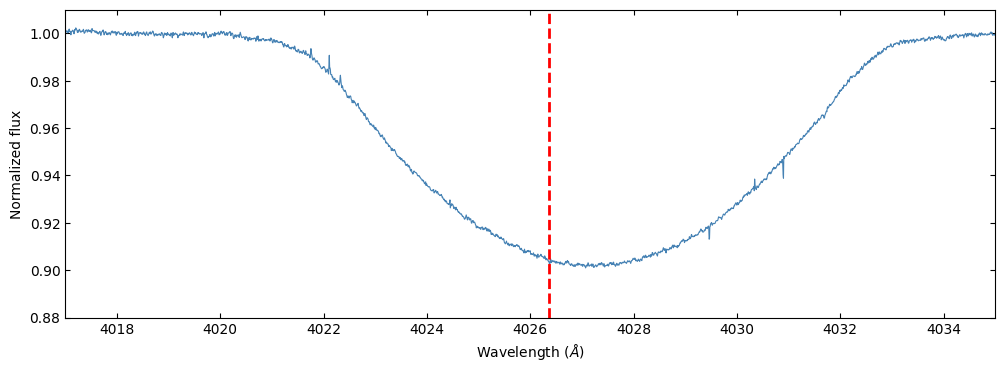

In [6]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(wavelength, flux, color="steelblue", linewidth=0.8)
ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_ylabel("Normalized flux")
ax.tick_params(direction="in", top=True, right=True)
ax.set_xlim(4017, 4035)
ax.set_ylim(0.88, 1.01)
ax.axvline(x=4026.36, color='red', linestyle='--', linewidth=2)
plt.show()

In [7]:
def rv_correct(wavelength, rv):
    c = 299792.458  # km/s
    beta = rv / c
    doppler_factor = np.sqrt((1.0 + beta) / (1.0 - beta))
    return np.asarray(wavelength) / doppler_factor
wavelength = rv_correct(wavelength, rv = 74) 

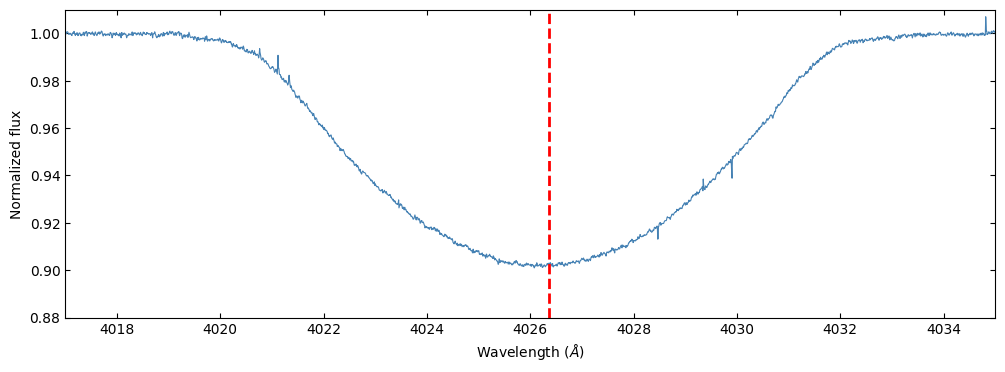

In [8]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(wavelength, flux, color="steelblue", linewidth=0.8)
ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_ylabel("Normalized flux")
ax.tick_params(direction="in", top=True, right=True)
ax.set_xlim(4017, 4035)
ax.set_ylim(0.88, 1.01)
ax.axvline(x=4026.36, color='red', linestyle='--', linewidth=2)
plt.show()

In [9]:
# The uncerstainties are used as weights. Replace the corresponding SNR for the spectrum - or use the flux errors for individual wavelength bins if available, directly.
SNR = 600.0 
flux_uncertainty = np.full_like(flux, 1.0 / SNR)

# make a spectrum object
spectrum = spfit.Spectrum(wavelength=wavelength, flux=flux,uncertainty=flux_uncertainty) #added an offset of 0.9 to put the line in the line centre temporarily

In [10]:
print(spectrum)
print(f"Number of wavelength points: {wavelength.size}")
print(f"Wavelength range: {wavelength.min():.2f} -- {wavelength.max():.2f} Å")
print(f"Assumed flux uncertainty: {1.0 / SNR:.5f}")

Spectrum(name=None, size=43364, n_lines=0, n_fitting_pixels=0)
Number of wavelength points: 43364
Wavelength range: 3999.01 -- 4298.93 Å
Assumed flux uncertainty: 0.00167


#### Add and Remove lines for analysis

add_line takes the nmae of the line species that you want to add. The name should be same as used by SPAMMS (i.e. in capital letters )

remove_line only needs the species names for removing a line from the selected linelist.

Overwrite option is to replace an already added line with updated fitting ranges

In [ ]:
spectrum.add_line(name="HEI4026", fitting_range=(4017.0, 4035.0), overwrite = True) 
spectrum.add_line(name="HEII4200", fitting_range=(4180.0, 4220.0), overwrite = True)
print("Selected lines:", spectrum.line_names)

In [ ]:
spectrum.remove_line("HEII4200")
print("Selected lines after removal:", spectrum.line_names)

#### Set the input file and parameter sets for fitting

parameters.fix for setting a parameter to a constant value.

Only the free paramteres will enter the optimization. The parameter bounds should be provided as (lower_bound, upper_bound)

In [17]:
parameters = spfit.ParameterSet(input_file=SPAMMS_DIR / "input.txt")
parameters.fix(teff=38000, r_pole=7, mass=20)
parameters.free(inclination=(30.0, 90.0), v_crit_frac=(0.3, 0.8), sigma_R=(50.0, 400.0), sigma_T=(50.0, 400.0))

In [ ]:
print(parameters.summary())
print("Free parameters:", parameters.free_names())
print("Initial vector:", parameters.initial_vector())
print("Bounds:", parameters.continuous_bounds())

#### pre-fitting steps

Next step is to create a spammsfit object with the spectrum, the parameter set and the temporary configuration we created previously

In [ ]:
spamms_fit = spfit.SpammsFit(spectrum=spectrum, parameters=parameters, config=config)
print(spamms_fit.summary())

For a bayesian_fit object, once should check the recommended minimum resources needed for the fit 

In [ ]:
bayesian_fit = spfit.BayesianFit(spamms_fit=spamms_fit)
print(bayesian_fit)

recommendations = bayesian_fit.resource_recommendations(ndim=parameters.n_free, nwalkers=16)
print('recommended respurces for bayesian fit: ', recommendations)

In [ ]:
result = bayesian_fit.run(nsteps=70, nwalkers=16, ncores=4, initial_guess=parameters.initial_vector(), burnin=20, thin=5, seed=1234,
    overwrite_backend=True, progress=True, show_recommendations=True)

In [ ]:
print(bayesian_fit.summary())
print(result.summary())

#### plotting functions

In [23]:
true_values = {"inclination": 60.0, "v_crit_frac": 0.6, "sigma_R": 200.0, "sigma_T": 350.0}

In [ ]:

trace_figure, trace_axes = spplot.plot_trace(result, true_values=true_values, save=config.results_directory / "trace_plot.png", show=True)

After only 30 iterations, we already converge quite a lot for $\sigma_T$ and $v/v_{crit}$. Ofcourse for a reliable solution, one needs to run a few more chains and atleast a few hundred steps. 

We recommend using a ncores = nwalkers in an available machine for a faster computation.

In [ ]:
corner_figure = spplot.plot_corner(result, true_values=true_values, save=config.results_directory / "corner_plot.png", show=True)

In [ ]:
fit_figure, fit_axes = spplot.plot_fit(result, lines=["HEI4026"], save=config.results_directory / "best_fit.png", show=True)

In [ ]:
fit_residual_figure, fit_residual_axes = spplot.plot_fit_with_residuals(result, line="HEI4026", show_uncertainty=True, 
                                                                        save=config.results_directory / "best_fit_with_residuals.png", show=True)